# InternShield: Fake Internship & Job Scam Detector

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

## Problem Statement
Fake job postings target students and job seekers through unrealistic pay, vague responsibilities, and suspicious payment requests. This project uses machine learning to identify potentially fraudulent job postings.


## Dataset
This dataset contains real and fake job postings with fields such as job title, company profile, description, requirements, benefits, and fraud label.

In [2]:
df = pd.read_csv("../data/fake_job_postings.csv")
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [3]:
df.shape

(17880, 18)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

In [5]:
df.columns

Index(['job_id', 'title', 'location', 'department', 'salary_range',
       'company_profile', 'description', 'requirements', 'benefits',
       'telecommuting', 'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent'],
      dtype='object')

In [6]:
df["fraudulent"].value_counts()


fraudulent
0    17014
1      866
Name: count, dtype: int64

In [7]:
df["fraudulent"].value_counts(normalize=True) * 100

fraudulent
0    95.1566
1     4.8434
Name: proportion, dtype: float64

## Approach
I combined multiple text fields into one job posting text, converted the text into TF-IDF features, and trained a Logistic Regression model.

In [8]:
text_columns = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits",
    "employment_type",
    "required_experience",
    "required_education",
    "industry",
    "function"
]

for col in text_columns:
    df[col] = df[col].fillna("")

df["combined_text"] = df[text_columns].agg(" ".join, axis=1)

df[["combined_text", "fraudulent"]].head()

,combined_text,fraudulent
0,"Marketing Intern We're Food52, and we've creat...",0
1,Customer Service - Cloud Video Production 90 S...,0
2,Commissioning Machinery Assistant (CMA) Valor ...,0
3,Account Executive - Washington DC Our passion ...,0
4,Bill Review Manager SpotSource Solutions LLC i...,0


In [9]:
X = df["combined_text"]
y = df["fraudulent"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [11]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [12]:
model = LogisticRegression(max_iter=1000, class_weight="balanced")

model.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [13]:
y_pred = model.predict(X_test_tfidf)

In [14]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9681208053691275


## Evaluation
Because fake jobs are less common than real jobs, I evaluated the model using precision, recall, F1-score, and confusion matrix.

In [15]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      3403
           1       0.62      0.90      0.73       173

    accuracy                           0.97      3576
   macro avg       0.81      0.93      0.86      3576
weighted avg       0.98      0.97      0.97      3576



In [16]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[3307,   96],
       [  18,  155]])

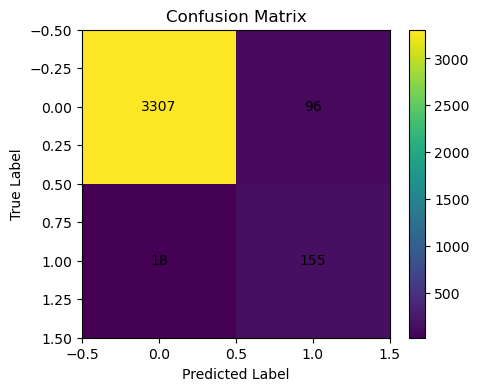

In [17]:
plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

for i in range(len(cm)):
    for j in range(len(cm[i])):
        plt.text(j, i, cm[i][j], ha="center", va="center")

plt.show()

## Result
The model predicts whether a job posting is likely real or fraudulent and provides a scam risk score.

In [18]:
sample_job = """
We are hiring immediately for a remote internship. No experience required.
You can earn $80 per hour working from home. We will send you a check
to buy your equipment. Training starts tomorrow.
"""

sample_tfidf = vectorizer.transform([sample_job])
prediction = model.predict(sample_tfidf)
probability = model.predict_proba(sample_tfidf)

print("Prediction:", prediction[0])
print("Fake job probability:", probability[0][1])

Prediction: 1
Fake job probability: 0.7428239841751845


In [25]:
risk_score = probability[0][1] * 100

if risk_score >= 75:
    risk_level = "High Risk Scam"
elif risk_score >= 40:
    risk_level = "Suspicious"
else:
    risk_level = "Likely Legit"

print("Risk Level:", risk_level)
print(f"Scam Risk Score: {risk_score:.2f}%")

Risk Level: Suspicious
Scam Risk Score: 74.28%


In [26]:
def detect_red_flags(text):
    text = text.lower()
    
    red_flags = []

    scam_keywords = {
        "Unusually high pay": ["$80", "$100", "high pay", "earn money fast", "weekly pay"],
        "Check or equipment scam language": ["send you a check", "deposit a check", "buy equipment", "purchase equipment"],
        "Urgent hiring language": ["hiring immediately", "urgent", "start tomorrow", "immediate start"],
        "No experience required": ["no experience", "no experience required"],
        "Suspicious payment language": ["wire transfer", "western union", "moneygram", "bitcoin", "crypto"],
        "Personal information request": ["ssn", "social security", "bank account", "passport"]
    }

    for reason, keywords in scam_keywords.items():
        for keyword in keywords:
            if keyword in text:
                red_flags.append(reason)
                break

    return red_flags

In [27]:
flags = detect_red_flags(sample_job)
flags

['Unusually high pay',
 'Check or equipment scam language',
 'Urgent hiring language',
 'No experience required']

In [28]:
def analyze_job_posting(job_text):
    job_tfidf = vectorizer.transform([job_text])
    prediction = model.predict(job_tfidf)[0]
    probability = model.predict_proba(job_tfidf)[0][1]
    red_flags = detect_red_flags(job_text)

    if probability >= 0.75:
        risk_level = "High Risk Scam"
    elif probability >= 0.40:
        risk_level = "Suspicious"
    else:
        risk_level = "Likely Legit"

    return {
        "prediction": int(prediction),
        "risk_level": risk_level,
        "risk_score": round(probability * 100, 2),
        "red_flags": red_flags
    }

In [29]:
analyze_job_posting(sample_job)

{'prediction': 1,
 'risk_level': 'Suspicious',
 'risk_score': np.float64(74.28),
 'red_flags': ['Unusually high pay',
  'Check or equipment scam language',
  'Urgent hiring language',
  'No experience required']}

In [30]:
joblib.dump(model, "../models/fake_job_model.pkl")
joblib.dump(vectorizer, "../models/tfidf_vectorizer.pkl")

['../models/tfidf_vectorizer.pkl']